# 🏎️ F1 Race Predictor — Sprint 1 EDA

**Goal:** Understand the structure and patterns in historical F1 race results
before we build any predictive model.

**Data source:** Ergast Motor Racing API (free, no key required)
**Seasons analysed:** 2018–2023 (6 seasons, ~138 races, ~2,700+ results)

**Key questions we want to answer:**
1. How strongly does grid position predict finishing position?
2. Which constructors are most dominant?
3. How often do drivers finish vs retire?
4. Are there patterns in points distribution across positions?

In [1]:
# ----- Imports -----
import sys
import time
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Add the project root to sys.path so we can import our src module
# This is necessary because notebooks/ is a subdirectory
sys.path.append(str(Path("..").resolve()))

from project1_race_predictor.src.data_fetcher import ErgastClient

# ----- Plot styling -----
# A consistent visual style makes your notebook look professional
sns.set_theme(style="darkgrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

# F1-inspired colour palette — one colour per constructor (Sprint 2 will expand this)
CONSTRUCTOR_COLOURS = {
    "red_bull":   "#3671C6",
    "ferrari":    "#E8002D",
    "mercedes":   "#27F4D2",
    "mclaren":    "#FF8000",
    "alpine":     "#FF87BC",
    "aston_martin": "#229971",
    "williams":   "#64C4FF",
    "haas":       "#B6BABD",
    "sauber":     "#52E252",
    "rb":         "#6692FF",
}

print("✅ Imports ready")

✅ Imports ready


In [10]:
# # ----- Data Fetching -----
# # We fetch 6 seasons (2018–2023) to give our model enough history.
# # 2018 is a good start - captures the hybrid era with consistent regulations.
# #
# # This will take ~2 minutes due to the 0.3s delay between API calls
# # (we're being polite to the free API - like waiting your turn at the pit entry).

# client = ErgastClient()
# SEASONS = range(2018, 2026)   # 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025

# for season in SEASONS:
#     print(f"Fetching season {season}...", end=" ")
#     df_raw = client.get_season_results(season=season)
    
#     print(f"✅ {len(df_raw)} results")
#     time.sleep(1)   # extra pause between seasons

#     # Save raw data so we don't need to re-fetch every time we open the notebook
#     raw_path = Path(f"../data/raw/race_results_{season}.csv")
#     raw_path.parent.mkdir(parents=True, exist_ok=True)
#     df_raw.to_csv(raw_path, index=False)

#     print(f"\n📦 Raw data saved → {raw_path}")
#     print(f"📐 Shape: {df_raw.shape[0]} rows × {df_raw.shape[1]} columns")

In [ ]:
# ── Load from Cache ───────────────────────────────────────────────────────────
# After the first run, load from the saved CSVs instead of hitting the API again.

raw_dir = Path("../data/raw")
csv_files = sorted(raw_dir.glob("race_results_*.csv"))

df_raw = pd.concat([pd.read_csv(f) for f in csv_files], ignore_index=True)

print(f"📂 Files loaded: {[f.name for f in csv_files]}")
print(f"📐 Shape: {df_raw.shape[0]} rows × {df_raw.shape[1]} columns")


📂 Files loaded: ['race_results_2018.csv', 'race_results_2019.csv', 'race_results_2020.csv', 'race_results_2021.csv', 'race_results_2022.csv', 'race_results_2023.csv', 'race_results_2024.csv', 'race_results_2025.csv']
📐 Shape: 3458 rows × 11 columns


In [11]:
# ----- First Look -----
# Like walking the track on Thursday - get familiar with what we're working with.

print("=== Schema ===")
print(df_raw.dtypes)
print("\n=== First 5 rows ===")
df_raw.head()

=== Schema ===
season                int64
round                 int64
position              int64
driver_id            object
driver_name          object
constructor          object
grid                  int64
laps                  int64
status               object
points              float64
fastest_lap_rank      int64
dtype: object

=== First 5 rows ===


,season,round,position,driver_id,driver_name,constructor,grid,laps,status,points,fastest_lap_rank
0,2018,1,1,vettel,Sebastian Vettel,ferrari,3,58,Finished,25.0,4
1,2018,1,2,hamilton,Lewis Hamilton,mercedes,1,58,Finished,18.0,3
2,2018,1,3,raikkonen,Kimi Räikkönen,ferrari,2,58,Finished,15.0,2
3,2018,1,4,ricciardo,Daniel Ricciardo,red_bull,8,58,Finished,12.0,1
4,2018,1,5,alonso,Fernando Alonso,mclaren,10,58,Finished,10.0,7


In [12]:
# ----- Data Quality Check -----
# Before any analysis, check for missing values and unexpected data types.
# Finding a data quality issue here is far cheaper than finding it in production.

print("=== Missing values per column ===")
missing = df_raw.isnull().sum()
print(missing[missing > 0] if missing.any() else "✅ No missing values")

print("\n=== Unique value counts ===")
for col in ["season", "constructor", "status"]:
    print(f"  {col}: {df_raw[col].nunique()} unique values")

print("\n=== Finish status distribution (top 10) ===")
print(df_raw["status"].value_counts().head(10))

=== Missing values per column ===
✅ No missing values

=== Unique value counts ===
  season: 8 unique values
  constructor: 16 unique values
  status: 54 unique values

=== Finish status distribution (top 10) ===
status
Finished            1995
+1 Lap               536
Lapped               297
Retired              161
+2 Laps              101
Collision             77
Accident              35
Engine                31
Collision damage      29
Brakes                20
Name: count, dtype: int64


## 🔍 Question 1: How strongly does grid position predict finishing position?

Grid position (qualifying result) is arguably the single most predictive feature
in any F1 race model. Let's quantify and visualise this relationship.

Pearson correlation (grid vs finish): 0.709


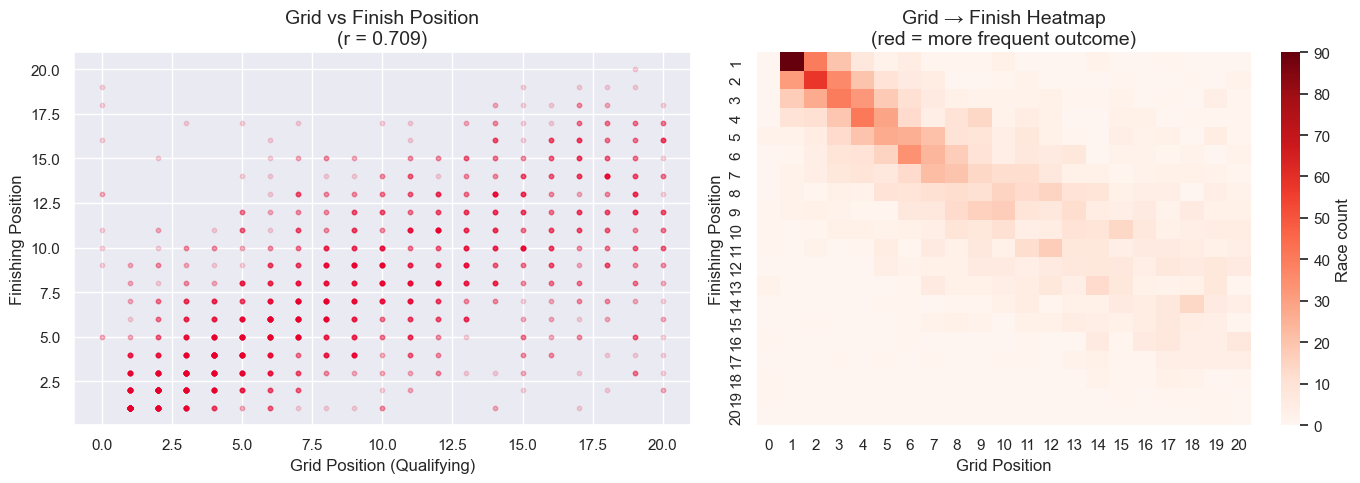

💾 Plot saved


In [14]:
# ----- Grid vs Finishing Position -----
# Core hypothesis: drivers who qualify higher tend to finish higher.
# We expect a strong positive correlation.

# Filter to classified finishers only (exclude retirements for this analysis)
df_finished = df_raw[df_raw["status"] == "Finished"].copy()

# Pearson correlation coefficient — ranges from -1 to +1
# +1 = perfect positive correlation (higher grid → higher finish)
# In F1, higher position number = worse result, so we expect a strong positive r
correlation = df_finished["grid"].corr(df_finished["position"])
print(f"Pearson correlation (grid vs finish): {correlation:.3f}")

# Scatter plot with regression line
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: scatter plot
axes[0].scatter(
    df_finished["grid"],
    df_finished["position"],
    alpha=0.15,        # transparency — reveals density in overlapping points
    color="#E8002D",
    s=10
)
axes[0].set_xlabel("Grid Position (Qualifying)")
axes[0].set_ylabel("Finishing Position")
axes[0].set_title(f"Grid vs Finish Position\n(r = {correlation:.3f})")

# Right: heatmap — shows where the mass of results sits
pivot = df_finished.groupby(
    ["grid", "position"]
).size().reset_index(name="count")

heatmap_data = pivot.pivot(index="position", columns="grid", values="count").fillna(0)
sns.heatmap(
    heatmap_data,
    ax=axes[1],
    cmap="Reds",
    cbar_kws={"label": "Race count"},
    linewidths=0
)
axes[1].set_title("Grid → Finish Heatmap\n(red = more frequent outcome)")
axes[1].set_xlabel("Grid Position")
axes[1].set_ylabel("Finishing Position")

plt.tight_layout()
plt.savefig("../data/processed/plot_grid_vs_finish.png", dpi=150)
plt.show()
print("💾 Plot saved")

## 🏆 Question 2: Which constructors are most dominant?

Constructor (team) is a powerful proxy feature - it encodes car performance,
strategy quality, and resource levels all in one variable.

 constructor  avg_finish  total_points  race_entries  wins
    mercedes    5.473988        4297.5           346    55
    red_bull    6.251445        4194.5           346    75
     ferrari    6.904624        3365.5           346    19
     mclaren    8.479769        2483.0           346    21
racing_point   10.631579         283.0            76     1
     renault   10.779661         394.0           118     0
aston_martin   11.488987         572.0           227     0
      alpine   12.092105         518.0           228     1
  alphatauri   12.373494         306.0           166     1
  toro_rosso   12.690476         118.0            84     0
          rb   12.802083         128.0            96     0
        alfa   13.384615         147.0           208     0
      sauber   14.043478         122.0           138     0
        haas   14.101156         290.0           346     0
    williams   14.623188         206.0           345     0


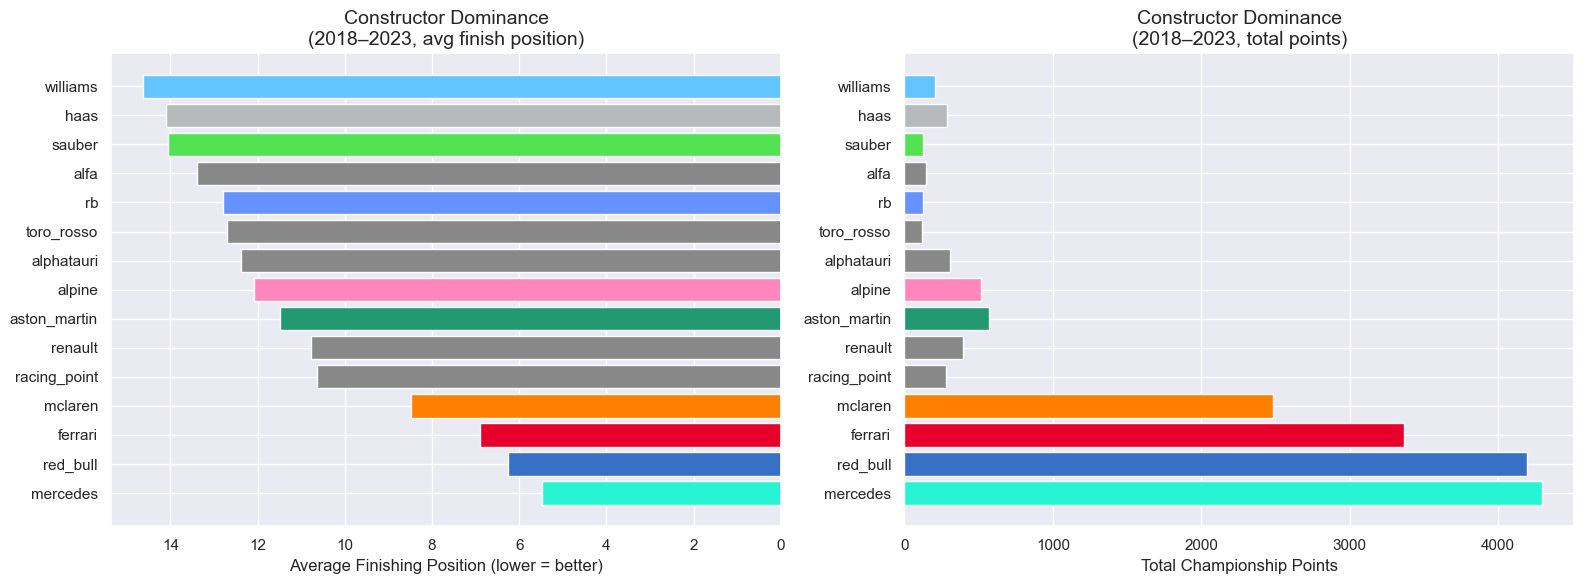

In [16]:
# ----- Constructor Dominance -----
# Two views: average finishing position and total points.
# Average finish position: lower number = better (1st place is best).

constructor_stats = (
    df_raw
    .groupby("constructor")
    .agg(
        avg_finish=("position", "mean"),
        total_points=("points", "sum"),
        race_entries=("position", "count"),
        wins=("position", lambda x: (x == 1).sum()),
    )
    .sort_values("avg_finish")
    .reset_index()
)

# Focus on constructors with meaningful sample size (>= 50 race entries)
constructor_stats = constructor_stats[constructor_stats["race_entries"] >= 50]

print(constructor_stats.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: average finishing position (lower = better → reverse x-axis)
colours = [
    CONSTRUCTOR_COLOURS.get(c, "#888888")
    for c in constructor_stats["constructor"]
]

axes[0].barh(
    constructor_stats["constructor"],
    constructor_stats["avg_finish"],
    color=colours
)
axes[0].invert_xaxis()   # lower avg finish = better = shown on the right
axes[0].set_xlabel("Average Finishing Position (lower = better)")
axes[0].set_title("Constructor Dominance\n(2018–2023, avg finish position)")

# Right: total points accumulated
axes[1].barh(
    constructor_stats["constructor"],
    constructor_stats["total_points"],
    color=colours
)
axes[1].set_xlabel("Total Championship Points")
axes[1].set_title("Constructor Dominance\n(2018–2023, total points)")

plt.tight_layout()
plt.savefig(
    "../data/processed/plot_constructor_dominance.png",
    dpi=150
)
plt.show()

## 🔧 Question 3: How often do drivers finish vs retire?

Retirement (DNF) is crucial to model - a driver starting from P3 who retires
contributes very different data to one who finishes P3.
We need to understand the DNF rate and what causes it.

C:\Users\puthr\AppData\Local\Temp\ipykernel_45688\607761570.py:48: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: (x["result_category"] == "DNF").sum() / len(x) * 100)
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


=== Result category distribution ===
result_category
Finished    1995
DNF          812
Lapped       651
Name: count, dtype: int64

DNF rate: 23.5%


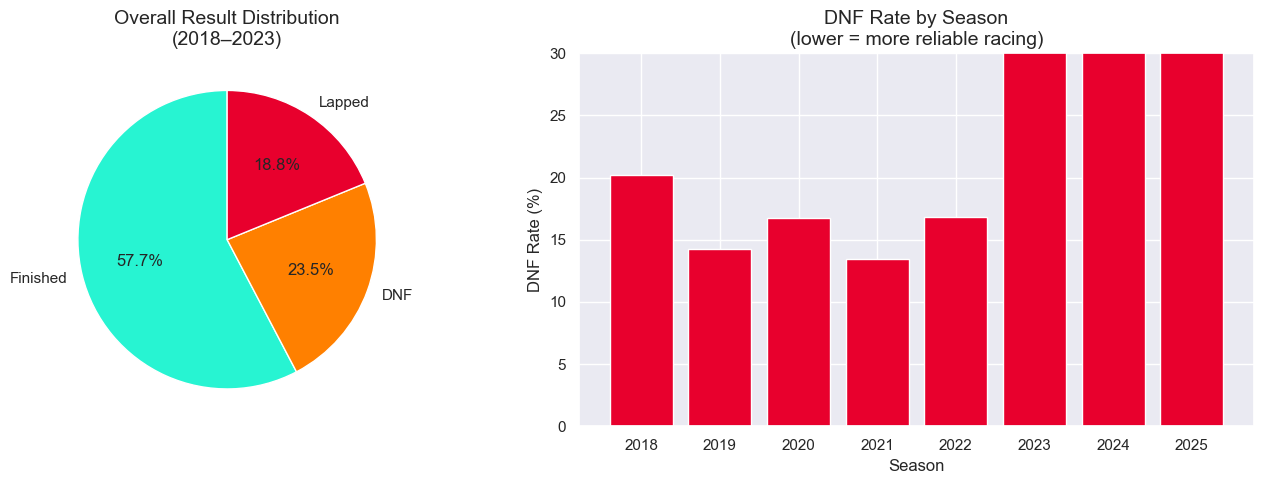

In [17]:
# ----- DNF Analysis -----
# Classify each result as Finished, Lapped (still running, down laps),
# or DNF (Did Not Finish — mechanical, accident, collision).

def classify_status(status: str) -> str:
    """
    Map Ergast status strings into three clean categories.

    Args:
        status: Raw status from Ergast e.g. "Finished", "+1 Lap", "Engine"

    Returns:
        One of: "Finished", "Lapped", "DNF"
    """
    if status == "Finished":
        return "Finished"
    elif status.startswith("+"):
        # "+1 Lap", "+2 Laps" etc. — still classified, just lapped
        return "Lapped"
    else:
        return "DNF"


df_raw["result_category"] = df_raw["status"].apply(classify_status)

# Overall distribution
category_counts = df_raw["result_category"].value_counts()
print("=== Result category distribution ===")
print(category_counts)
print(f"\nDNF rate: {category_counts['DNF'] / len(df_raw) * 100:.1f}%")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: pie chart of overall distribution
axes[0].pie(
    category_counts,
    labels=category_counts.index,
    autopct="%1.1f%%",
    colors=["#27F4D2", "#FF8000", "#E8002D"],
    startangle=90,
)
axes[0].set_title("Overall Result Distribution\n(2018–2023)")

# Right: DNF rate per season — are races getting more or less reliable?
dnf_by_season = (
    df_raw
    .groupby("season")
    .apply(lambda x: (x["result_category"] == "DNF").sum() / len(x) * 100)
    .reset_index(name="dnf_rate_pct")
)

axes[1].bar(
    dnf_by_season["season"].astype(str),
    dnf_by_season["dnf_rate_pct"],
    color="#E8002D"
)
axes[1].set_xlabel("Season")
axes[1].set_ylabel("DNF Rate (%)")
axes[1].set_title("DNF Rate by Season\n(lower = more reliable racing)")
axes[1].set_ylim(0, 30)

plt.tight_layout()
plt.savefig(
    "../data/processed/plot_dnf_analysis.png",
    dpi=150
)
plt.show()

## 📊 Question 4: Points distribution across positions

Understanding how points are distributed tells us about class separation -
how different is finishing P1 vs P3 vs P10?
This will influence whether we frame our model as regression or classification.

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


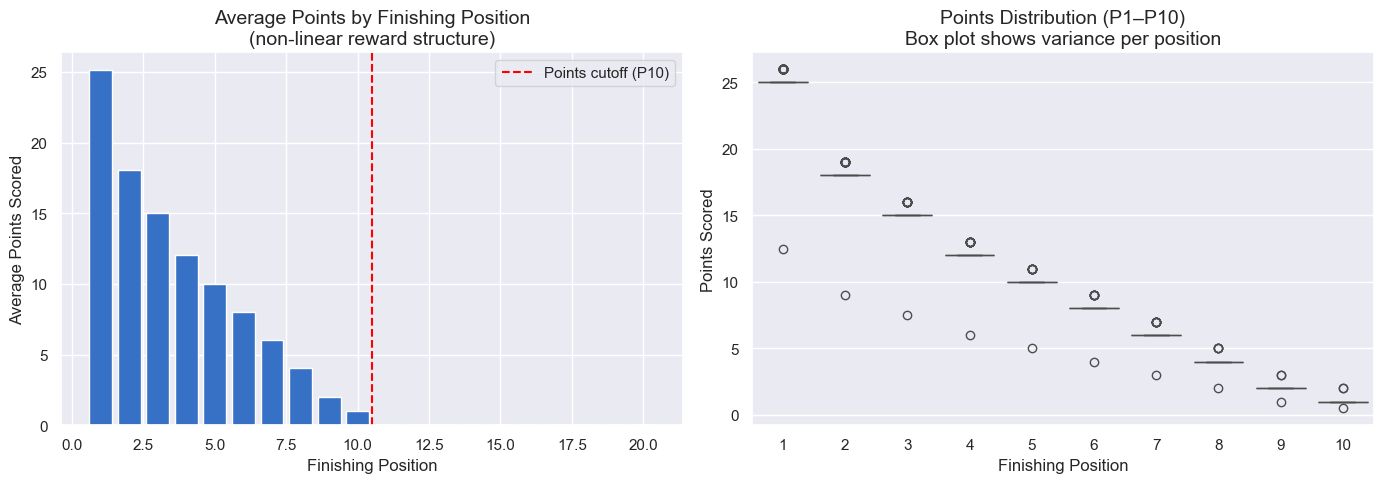

In [18]:
# ----- Points Distribution -----
# F1 points system: 25-18-15-12-10-8-6-4-2-1 for P1–P10, 0 beyond P10.
# This is a non-linear reward — winning is disproportionately valuable.

points_by_position = (
    df_raw[df_raw["result_category"] == "Finished"]
    .groupby("position")["points"]
    .mean()
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: average points per finishing position
axes[0].bar(
    points_by_position["position"],
    points_by_position["points"],
    color="#3671C6"
)
axes[0].set_xlabel("Finishing Position")
axes[0].set_ylabel("Average Points Scored")
axes[0].set_title("Average Points by Finishing Position\n(non-linear reward structure)")
axes[0].axvline(x=10.5, color="red", linestyle="--", label="Points cutoff (P10)")
axes[0].legend()

# Right: box plot of points per position (shows variance)
top10 = df_raw[df_raw["position"] <= 10]
sns.boxplot(
    data=top10,
    x="position",
    y="points",
    ax=axes[1],
    color="#FF8000"
)
axes[1].set_xlabel("Finishing Position")
axes[1].set_ylabel("Points Scored")
axes[1].set_title("Points Distribution (P1–P10)\nBox plot shows variance per position")

plt.tight_layout()
plt.savefig(
    "../data/processed/plot_points_distribution.png",
    dpi=150
)
plt.show()

## ✅ EDA Summary - Key Findings

| Finding | Implication for Modelling |
|---|---|
| Grid position has strong positive correlation with finish | Include `grid` as a primary feature |
| Constructor explains significant variance in results | Encode `constructor` as a categorical feature |
| DNF rate ~15-20% - not ignorable | Model DNFs separately or use classification with a "DNF" class |
| Points system is non-linear | Use finishing position as target, not points |
| 2021 season shows regulation-driven competitiveness spike | Consider season as a feature to capture regulation eras |

**Next:** Feature engineering - we'll encode these insights into model-ready features.